# Segmentation de tumeurs/AVC (Brain Stroke CT) avec DeepLabV3

Ce notebook entraîne **DeepLabV3** (ResNet50 pré-entraîné, torchvision) pour la segmentation sur le dataset :

```
/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset
```

⚠️ **Important** : je n'ai pas pu inspecter directement la structure exacte de ce dataset (arborescence, format des masques). La **Cellule 2** ci-dessous explore automatiquement le dossier `/kaggle/input/...` et affiche son contenu (sous-dossiers, extensions de fichiers, quelques exemples de chemins).

**À faire avant de lancer l'entraînement complet** :
1. Exécuter les cellules 1 à 3 (imports + exploration).
2. Regarder la sortie de la cellule d'exploration.
3. Ajuster dans la cellule **CONFIG** les variables `IMG_DIR` / `MASK_DIR` (ou la logique de `build_pairs()` si la structure est différente de celle supposée par défaut).
4. Relancer tout le notebook.

Le notebook gère par défaut 2 structures courantes :
- `images/` + `masks/` (ou `labels/`, `segmentations/`) avec noms de fichiers identiques
- une seule arborescence où chaque image a un masque avec un suffixe (`_mask`, `_seg`, etc.)

Si le dataset a une structure très différente (ex: fichiers `.npy`, `.nii`, COCO json...), il faudra adapter la fonction `build_pairs()`.


## 1. Installation et imports

In [1]:
# Sur Kaggle, la plupart de ces packages sont déjà installés.
# Décommentez si besoin (nécessite l'accès Internet activé sur le notebook Kaggle : Settings > Internet > On).
# !pip install -q albumentations opencv-python-headless

import os
import re
import glob
import random
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))


/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


Device utilisé : cuda
GPU : Tesla T4


## 2. Exploration du dataset (à exécuter et lire en premier !)

In [2]:
DATASET_ROOT = "/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset"

if not os.path.exists(DATASET_ROOT):
    # Chemins alternatifs observés sur Kaggle selon la façon dont le dataset est monté
    alternatives = [
        "/kaggle/input/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset",
        "/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset",
        "/kaggle/input/brain-stroke-ct-dataset",
    ]
    print(f"Chemin non trouvé : {DATASET_ROOT}")
    for alt in alternatives:
        print(f"Essai du chemin alternatif : {alt}")
        if os.path.exists(alt):
            DATASET_ROOT = alt
            break

print("Racine du dataset :", DATASET_ROOT)
print("Existe :", os.path.exists(DATASET_ROOT))
print("Contenu :", os.listdir(DATASET_ROOT) if os.path.exists(DATASET_ROOT) else "N/A")
print()

def explore(root, max_depth=3, max_files_per_dir=5):
    root = Path(root)
    for dirpath, dirnames, filenames in os.walk(root):
        depth = len(Path(dirpath).relative_to(root).parts)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{Path(dirpath).name}/  ({len(filenames)} fichiers)")
        for f in sorted(filenames)[:max_files_per_dir]:
            print(f"{indent}  - {f}")
        if len(filenames) > max_files_per_dir:
            print(f"{indent}  ... (+{len(filenames) - max_files_per_dir} autres)")

explore(DATASET_ROOT)

# Compte des extensions de fichiers sur tout l'arbre (utile pour repérer masques/images/annotations)
ext_counts = {}
for dirpath, _, filenames in os.walk(DATASET_ROOT):
    for f in filenames:
        ext = Path(f).suffix.lower()
        ext_counts[ext] = ext_counts.get(ext, 0) + 1

print("\nComptage des extensions de fichiers dans tout le dataset :")
for ext, cnt in sorted(ext_counts.items(), key=lambda x: -x[1]):
    print(f"  {ext or '(sans extension)'} : {cnt}")

# --- Exploration détaillée par classe (Ischemia / Bleeding / Normal / External_Test) ---
# D'après `os.listdir(DATASET_ROOT)`, ce dataset est organisé par CLASSE et non par paires image/masque.
print("\n--- Détail par sous-dossier (classe) ---")
for sub in sorted(os.listdir(DATASET_ROOT)):
    subpath = os.path.join(DATASET_ROOT, sub)
    if not os.path.isdir(subpath):
        continue
    all_files = []
    for dirpath, dirnames, filenames in os.walk(subpath):
        all_files.extend(os.path.join(dirpath, f) for f in filenames)
    sub_exts = {}
    for f in all_files:
        e = Path(f).suffix.lower()
        sub_exts[e] = sub_exts.get(e, 0) + 1
    print(f"{sub}/ : {len(all_files)} fichiers au total, extensions = {sub_exts}")
    # Sous-dossiers immédiats à l'intérieur de la classe (ex: 'images', 'masks' si présents)
    immediate_subdirs = [d for d in os.listdir(subpath) if os.path.isdir(os.path.join(subpath, d))]
    print(f"   sous-dossiers immédiats : {immediate_subdirs}")
    print(f"   exemples de fichiers : {[os.path.basename(f) for f in all_files[:5]]}")

Racine du dataset : /kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset
Existe : True
Contenu : ['Ischemia', 'Bleeding', 'Normal', 'External_Test']

Brain_Stroke_CT_Dataset/  (0 fichiers)
  Ischemia/  (0 fichiers)
    DICOM/  (1130 fichiers)
      - 10003.dcm
      - 10017.dcm
      - 10024.dcm
      - 10028.dcm
      - 10038.dcm
      ... (+1125 autres)
    OVERLAY/  (1130 fichiers)
      - 10003.png
      - 10017.png
      - 10024.png
      - 10028.png
      - 10038.png
      ... (+1125 autres)
    PNG/  (1130 fichiers)
      - 10003.png
      - 10017.png
      - 10024.png
      - 10028.png
      - 10038.png
      ... (+1125 autres)
  Bleeding/  (0 fichiers)
    DICOM/  (1093 fichiers)
      - 10002.dcm
      - 10033.dcm
      - 10036.dcm
      - 10039.dcm
      - 10045.dcm
      ... (+1088 autres)
    OVERLAY/  (1093 fichiers)
      - 10002.png
      - 10033.png
      - 10036.png
      - 10039.png
      - 10045.png
      ... (+1088 autres)
    PNG/  (1

### ✅ Structure réelle du dataset (confirmée par votre exécution)

```
Ischemia/      DICOM/ (1130)  OVERLAY/ (1130)  PNG/ (1130)
Bleeding/      DICOM/ (1093)  OVERLAY/ (1093)  PNG/ (1093)
Normal/        DICOM/ (4427)                   PNG/ (4427)      <- pas d'OVERLAY (pas de lésion)
External_Test/ labels.csv  DICOM/ (200)  OVERLAY/ (200)  MASKS/ (200)  PNG/ (200)
```

**Point essentiel : seul `External_Test` contient un dossier `MASKS` (masque binaire réel).**
Pour `Ischemia`/`Bleeding`, on a seulement `OVERLAY` : l'image CT avec la lésion surlignée en couleur par-dessus l'image en niveaux de gris. On peut **reconstruire un masque approximatif** en détectant les pixels colorés (non-gris) de l'overlay — c'est une technique classique pour ce type de dataset.

**Stratégie retenue :**
1. `Ischemia` / `Bleeding` → masque = extrait automatiquement de `OVERLAY` (couleur ajoutée).
2. `Normal` → masque = tout à zéro (aucune lésion).
3. `External_Test` → on a la chance d'avoir le **vrai masque** (`MASKS/`) ET l'`OVERLAY` pour les mêmes images : on va donc **valider notre méthode d'extraction** en comparant masque-extrait vs vrai masque avant de lui faire confiance pour l'entraînement. `External_Test` sert ensuite de jeu de test final, séparé.

### Remarque
Les cellules suivantes utilisent directement cette structure (plus besoin de recherche automatique de dossiers "images"/"masks" génériques).

## 3. Configuration (⚠️ à adapter selon l'exploration ci-dessus)

In [3]:
class CONFIG:
    DATASET_ROOT = DATASET_ROOT

    CLASSES = ["Ischemia", "Bleeding", "Normal"]   # classes utilisées pour l'entraînement
    PNG_SUBDIR = "PNG"
    OVERLAY_SUBDIR = "OVERLAY"                        # absent pour Normal
    EXTERNAL_TEST_DIR = os.path.join(DATASET_ROOT, "External_Test")
    EXTERNAL_MASKS_SUBDIR = "MASKS"
    EXTERNAL_LABELS_CSV = os.path.join(EXTERNAL_TEST_DIR, "labels.csv")

    MASK_CACHE_DIR = "/kaggle/working/mask_cache"     # masques dérivés des OVERLAY, mis en cache ici

    # Seuils pour extraire le masque depuis l'OVERLAY (couleur ajoutée sur l'image grise)
    OVERLAY_SAT_THRESH = 30        # seuil de saturation HSV (0-255) au-dessus duquel un pixel est "coloré"
    OVERLAY_DIFF_THRESH = 25       # seuil de différence de niveaux de gris overlay vs image originale
    MASK_MIN_AREA = 15             # supprime les petits îlots de bruit (en pixels) après extraction

    IMG_SIZE = 256          # taille (H=W) après resize
    BATCH_SIZE = 8
    NUM_EPOCHS = 40
    LR = 1e-4
    VAL_SPLIT = 0.15
    NUM_WORKERS = 2
    IN_CHANNELS = 1         # 1 = niveaux de gris (CT scan), 3 = RGB
    BASE_FEATURES = 32      # nb de filtres de la première couche du U-Net
    THRESHOLD = 0.5         # seuil de binarisation du masque prédit
    CHECKPOINT_DIR = "/kaggle/working/checkpoints"
    BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "unet_best.pth")

os.makedirs(CONFIG.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CONFIG.MASK_CACHE_DIR, exist_ok=True)
print("Config prête. IMG_SIZE =", CONFIG.IMG_SIZE, "| BATCH_SIZE =", CONFIG.BATCH_SIZE)

Config prête. IMG_SIZE = 256 | BATCH_SIZE = 8


## 4. Extraction du masque depuis l'OVERLAY (et validation sur External_Test)

Validation sur 200 images de External_Test
Dice moyen (masque extrait de l'OVERLAY vs vrai masque) : 0.9995
Dice médian : 1.0000 | min : 0.9840 | max : 1.0000


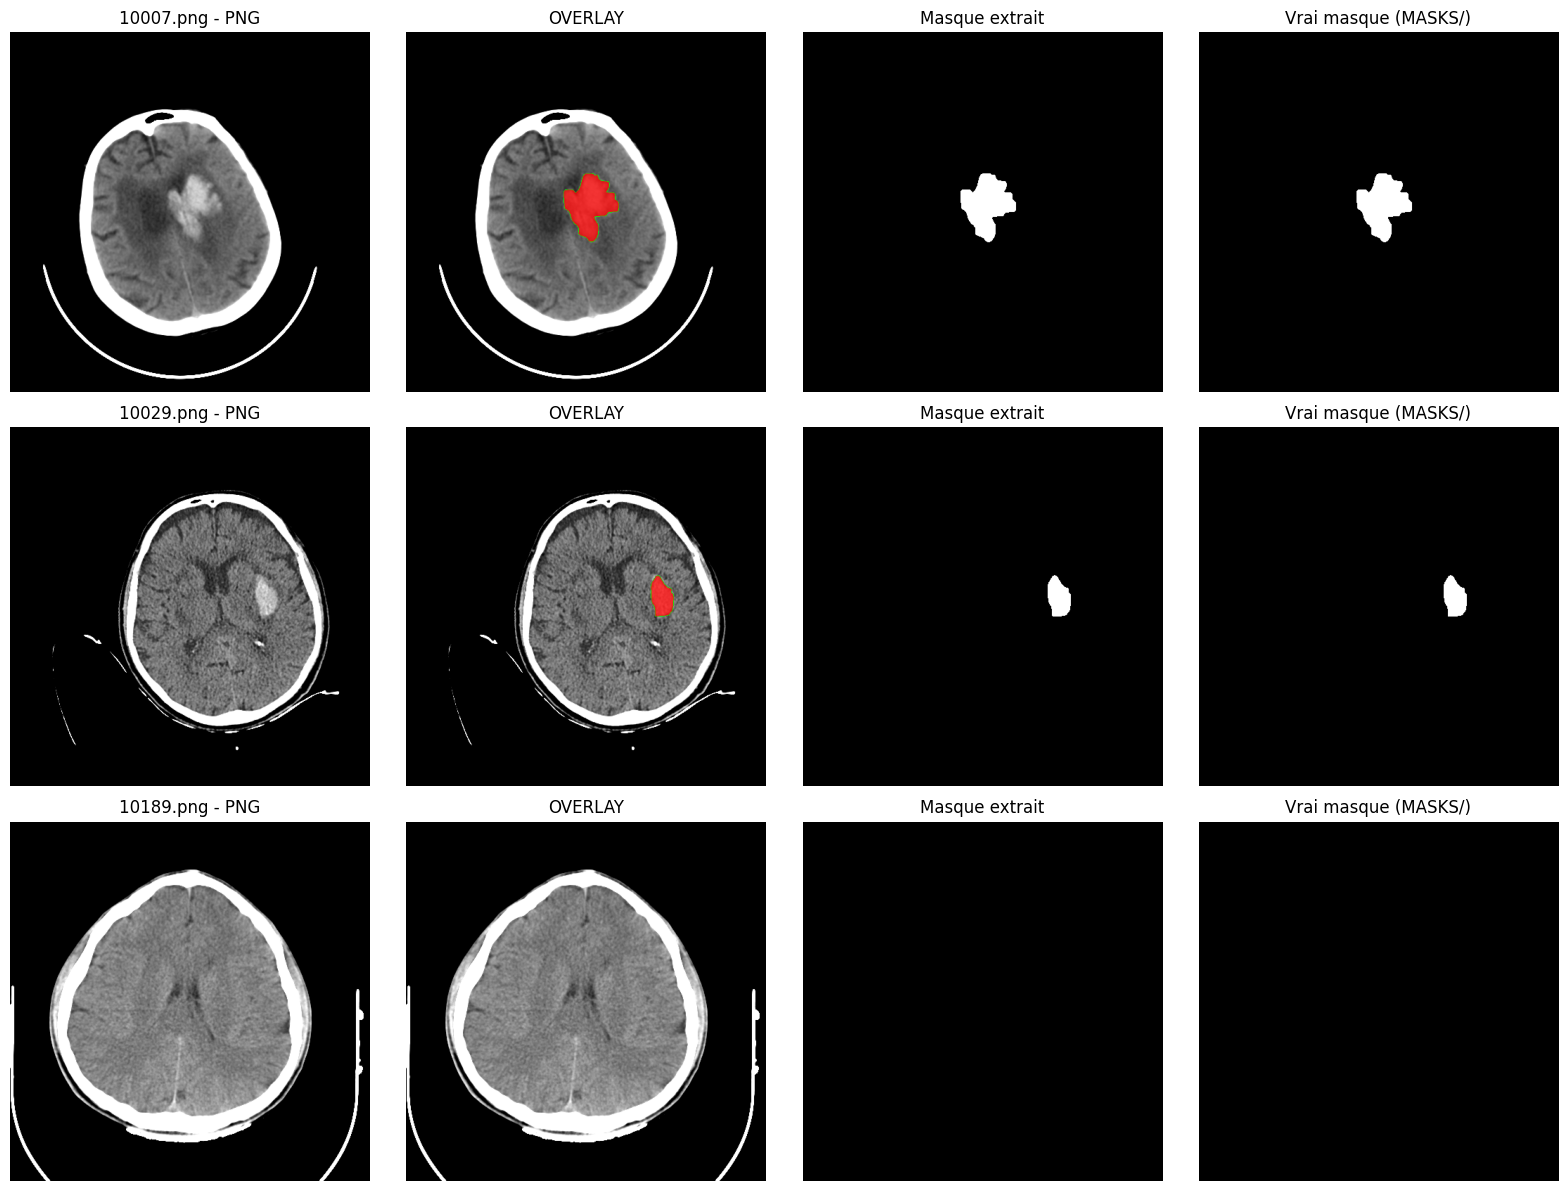


👉 Si le Dice moyen est élevé (ex: > 0.6-0.7), l'extraction depuis l'OVERLAY est fiable et on peut l'utiliser pour générer les masques d'entraînement de Ischemia/Bleeding.
   S'il est faible, il faudra ajuster OVERLAY_SAT_THRESH / OVERLAY_DIFF_THRESH dans CONFIG (cellule 3) et relancer cette cellule.


In [4]:
def extract_mask_from_overlay(png_path, overlay_path,
                               sat_thresh=CONFIG.OVERLAY_SAT_THRESH,
                               diff_thresh=CONFIG.OVERLAY_DIFF_THRESH,
                               min_area=CONFIG.MASK_MIN_AREA):
    """Reconstruit un masque binaire à partir d'une image en niveaux de gris (PNG) et de sa
    version OVERLAY (même image avec la lésion surlignée en couleur).
    Principe : un pixel appartient au masque s'il est 'coloré' (saturation HSV élevée) OU
    s'il diffère fortement en intensité de l'image d'origine."""
    gray = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    overlay_bgr = cv2.imread(overlay_path, cv2.IMREAD_COLOR)

    if gray is None or overlay_bgr is None:
        return None

    if overlay_bgr.shape[:2] != gray.shape[:2]:
        overlay_bgr = cv2.resize(overlay_bgr, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    hsv = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2HSV)
    saturation = hsv[..., 1]

    overlay_gray = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2GRAY)
    diff = cv2.absdiff(overlay_gray, gray)

    mask = ((saturation > sat_thresh) | (diff > diff_thresh)).astype(np.uint8) * 255

    # Nettoyage morphologique : enlève le bruit isolé, referme les petits trous
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Supprime les petites composantes connexes (bruit résiduel)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for lbl in range(1, n_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            clean[labels == lbl] = 255

    return clean


def dice_score(mask_a, mask_b):
    a = (mask_a > 0).astype(np.float32).ravel()
    b = (mask_b > 0).astype(np.float32).ravel()
    inter = (a * b).sum()
    denom = a.sum() + b.sum()
    return 1.0 if denom == 0 else (2 * inter) / denom


# --- Validation : comparer masque extrait vs vrai masque sur External_Test (qui a les deux) ---
ext_png_dir = os.path.join(CONFIG.EXTERNAL_TEST_DIR, CONFIG.PNG_SUBDIR)
ext_overlay_dir = os.path.join(CONFIG.EXTERNAL_TEST_DIR, CONFIG.OVERLAY_SUBDIR)
ext_mask_dir = os.path.join(CONFIG.EXTERNAL_TEST_DIR, CONFIG.EXTERNAL_MASKS_SUBDIR)

ext_files = sorted(os.listdir(ext_png_dir))
dice_scores = []
examples = []
for fname in ext_files:
    png_path = os.path.join(ext_png_dir, fname)
    overlay_path = os.path.join(ext_overlay_dir, fname)
    real_mask_path = os.path.join(ext_mask_dir, fname)
    if not (os.path.exists(overlay_path) and os.path.exists(real_mask_path)):
        continue
    extracted = extract_mask_from_overlay(png_path, overlay_path)
    real_mask = cv2.imread(real_mask_path, cv2.IMREAD_GRAYSCALE)
    if extracted is None or real_mask is None:
        continue
    if extracted.shape != real_mask.shape:
        extracted = cv2.resize(extracted, (real_mask.shape[1], real_mask.shape[0]), interpolation=cv2.INTER_NEAREST)
    d = dice_score(extracted, real_mask)
    dice_scores.append(d)
    if len(examples) < 3:
        examples.append((fname, png_path, overlay_path, extracted, real_mask))

print(f"Validation sur {len(dice_scores)} images de External_Test")
print(f"Dice moyen (masque extrait de l'OVERLAY vs vrai masque) : {np.mean(dice_scores):.4f}")
print(f"Dice médian : {np.median(dice_scores):.4f} | min : {np.min(dice_scores):.4f} | max : {np.max(dice_scores):.4f}")

fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
for i, (fname, png_path, overlay_path, extracted, real_mask) in enumerate(examples):
    img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    overlay_img = cv2.cvtColor(cv2.imread(overlay_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(img, cmap="gray"); axes[i, 0].set_title(f"{fname} - PNG")
    axes[i, 1].imshow(overlay_img); axes[i, 1].set_title("OVERLAY")
    axes[i, 2].imshow(extracted, cmap="gray"); axes[i, 2].set_title("Masque extrait")
    axes[i, 3].imshow(real_mask, cmap="gray"); axes[i, 3].set_title("Vrai masque (MASKS/)")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.show()

print("\n👉 Si le Dice moyen est élevé (ex: > 0.6-0.7), l'extraction depuis l'OVERLAY est fiable "
      "et on peut l'utiliser pour générer les masques d'entraînement de Ischemia/Bleeding.")
print("   S'il est faible, il faudra ajuster OVERLAY_SAT_THRESH / OVERLAY_DIFF_THRESH dans CONFIG "
      "(cellule 3) et relancer cette cellule.")

## 5. Construction des paires (image, masque) pour l'entraînement

- `Ischemia` / `Bleeding` : masque = extrait de l'`OVERLAY` (mis en cache sur disque).
- `Normal` : masque = image entièrement noire (aucune lésion).
- `External_Test` : **exclu** du train/val — gardé de côté comme jeu de test final avec les vrais masques.

In [5]:
def build_pairs():
    pairs = []  # liste de (img_path, mask_path)

    for cls in CONFIG.CLASSES:
        cls_dir = os.path.join(CONFIG.DATASET_ROOT, cls)
        png_dir = os.path.join(cls_dir, CONFIG.PNG_SUBDIR)
        overlay_dir = os.path.join(cls_dir, CONFIG.OVERLAY_SUBDIR)
        cache_dir = os.path.join(CONFIG.MASK_CACHE_DIR, cls)
        os.makedirs(cache_dir, exist_ok=True)

        if not os.path.isdir(png_dir):
            print(f"⚠️ Dossier introuvable, classe ignorée : {png_dir}")
            continue

        has_overlay = os.path.isdir(overlay_dir)
        fnames = sorted(os.listdir(png_dir))

        for fname in fnames:
            img_path = os.path.join(png_dir, fname)
            mask_path = os.path.join(cache_dir, fname)

            if not os.path.exists(mask_path):
                if has_overlay:
                    overlay_path = os.path.join(overlay_dir, fname)
                    if os.path.exists(overlay_path):
                        mask = extract_mask_from_overlay(img_path, overlay_path)
                    else:
                        mask = None
                else:
                    mask = None

                if mask is None:
                    # pas d'overlay (classe Normal) ou fichier manquant -> masque vide (pas de lésion)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        continue
                    mask = np.zeros_like(img, dtype=np.uint8)

                cv2.imwrite(mask_path, mask)

            pairs.append((img_path, mask_path))

    return pairs


all_pairs = build_pairs()
random.seed(42)
random.shuffle(all_pairs)

n_val = int(len(all_pairs) * CONFIG.VAL_SPLIT)
val_pairs = all_pairs[:n_val]
train_pairs = all_pairs[n_val:]

print(f"Total paires (Ischemia+Bleeding+Normal) : {len(all_pairs)}")
print(f"Train : {len(train_pairs)} | Val : {len(val_pairs)}")

# Paires de test final (External_Test, avec les VRAIS masques, pas ceux extraits)
ext_png_dir = os.path.join(CONFIG.EXTERNAL_TEST_DIR, CONFIG.PNG_SUBDIR)
ext_mask_dir = os.path.join(CONFIG.EXTERNAL_TEST_DIR, CONFIG.EXTERNAL_MASKS_SUBDIR)
external_test_pairs = [
    (os.path.join(ext_png_dir, f), os.path.join(ext_mask_dir, f))
    for f in sorted(os.listdir(ext_png_dir))
    if os.path.exists(os.path.join(ext_mask_dir, f))
]
print(f"External_Test (vrais masques) : {len(external_test_pairs)} images")

Total paires (Ischemia+Bleeding+Normal) : 6650
Train : 5653 | Val : 997
External_Test (vrais masques) : 200 images


## 6. Dataset PyTorch + augmentations

In [6]:
class SegmentationDataset(Dataset):
    def __init__(self, pairs, img_size, transform=None, in_channels=1):
        self.pairs = pairs
        self.img_size = img_size
        self.transform = transform
        self.in_channels = in_channels

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        if self.in_channels == 1:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            image = image[..., None]  # (H, W, 1)
        else:
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        # binarisation : tout pixel non nul = tumeur/lésion (classe positive)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        mask = mask.unsqueeze(0) if mask.ndim == 2 else mask
        return image, mask.float()


def get_transforms(img_size, train=True):
    if train:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=(0.5,) * CONFIG.IN_CHANNELS, std=(0.5,) * CONFIG.IN_CHANNELS),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.5,) * CONFIG.IN_CHANNELS, std=(0.5,) * CONFIG.IN_CHANNELS),
            ToTensorV2(),
        ])

train_dataset = SegmentationDataset(train_pairs, CONFIG.IMG_SIZE, get_transforms(CONFIG.IMG_SIZE, train=True), CONFIG.IN_CHANNELS)
val_dataset = SegmentationDataset(val_pairs, CONFIG.IMG_SIZE, get_transforms(CONFIG.IMG_SIZE, train=False), CONFIG.IN_CHANNELS)

train_loader = DataLoader(train_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=True,
                           num_workers=CONFIG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=False,
                         num_workers=CONFIG.NUM_WORKERS, pin_memory=True)

print(f"Batches train : {len(train_loader)} | Batches val : {len(val_loader)}")


Batches train : 706 | Batches val : 125


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 7. Aperçu visuel de quelques échantillons

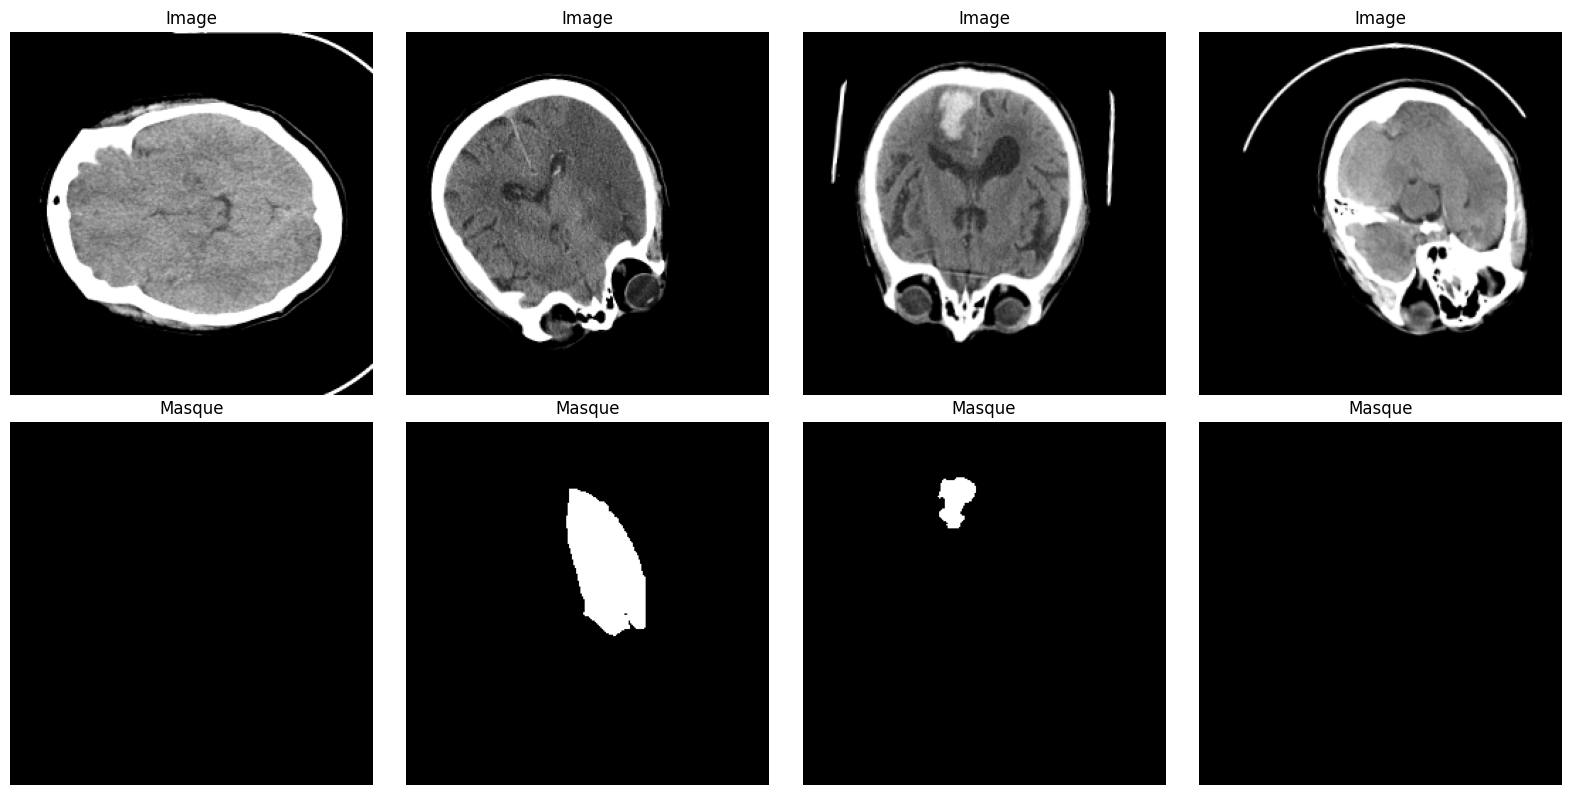

In [7]:
def denormalize(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5
    return np.clip(img, 0, 1)

sample_imgs, sample_masks = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(min(4, sample_imgs.shape[0])):
    img = denormalize(sample_imgs[i])
    mask = sample_masks[i, 0].numpy()
    axes[0, i].imshow(img.squeeze(), cmap="gray" if CONFIG.IN_CHANNELS == 1 else None)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title("Masque")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## 8. Architecture DeepLabV3 (ResNet50, pré-entraîné ImageNet, via torchvision)

On remplace le U-Net « from scratch » par **DeepLabV3** (backbone ResNet50 pré-entraîné). Comme les CT sont en niveaux de gris (1 canal) et que le backbone attend du RGB (3 canaux), la première conv du backbone est adaptée automatiquement : ses poids pré-entraînés sont moyennés sur les 3 canaux RGB pour initialiser le(s) canal(aux) niveau de gris — on garde ainsi le bénéfice du pré-entraînement au lieu de réinitialiser cette couche au hasard.

In [8]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from urllib.error import URLError


def build_deeplabv3(in_channels=1, num_classes=1, pretrained=True):
    if pretrained:
        weights = DeepLabV3_ResNet50_Weights.DEFAULT
        base_model = deeplabv3_resnet50(weights=weights, aux_loss=True)
    else:
        # weights_backbone=None est indispensable : sinon torchvision télécharge quand même
        # les poids ImageNet du backbone ResNet50 par défaut, même si weights=None.
        base_model = deeplabv3_resnet50(weights=None, weights_backbone=None, aux_loss=False)

    # --- Adapter la première conv du backbone si l'entrée n'est pas en 3 canaux (RGB) ---
    if in_channels != 3:
        old_conv = base_model.backbone.conv1
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=(old_conv.bias is not None),
        )
        if pretrained:
            with torch.no_grad():
                mean_weight = old_conv.weight.mean(dim=1, keepdim=True)
                new_conv.weight.copy_(mean_weight.repeat(1, in_channels, 1, 1))
        base_model.backbone.conv1 = new_conv

    # --- Remplace la tête de classification pour la segmentation binaire (1 canal de sortie) ---
    base_model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    if base_model.aux_classifier is not None:
        base_model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

    return base_model


class DeepLabV3Wrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x)["out"]


CONFIG.PRETRAINED = True  # nécessite Internet activé sur Kaggle (Settings > Internet > On)

try:
    base_model = build_deeplabv3(in_channels=CONFIG.IN_CHANNELS, num_classes=1, pretrained=CONFIG.PRETRAINED)
except URLError:
    print("⚠️ Impossible de télécharger les poids pré-entraînés (Internet désactivé sur ce notebook).")
    print("   -> Activez Settings > Internet > On puis relancez cette cellule pour avoir le pré-entraînement,")
    print("      OU continuez sans pré-entraînement (fonctionne hors-ligne, juste moins performant au départ).")
    CONFIG.PRETRAINED = False
    base_model = build_deeplabv3(in_channels=CONFIG.IN_CHANNELS, num_classes=1, pretrained=False)

model = DeepLabV3Wrapper(base_model).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modèle : DeepLabV3 (ResNet50, pretrained={CONFIG.PRETRAINED})")
print(f"Nombre de paramètres entraînables : {n_params:,}")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
⚠️ Impossible de télécharger les poids pré-entraînés (Internet désactivé sur ce notebook).
   -> Activez Settings > Internet > On puis relancez cette cellule pour avoir le pré-entraînement,
      OU continuez sans pré-entraînement (fonctionne hors-ligne, juste moins performant au départ).
Modèle : DeepLabV3 (ResNet50, pretrained=False)
Nombre de paramètres entraînables : 39,627,457


## 9. Fonctions de perte et métriques (Dice + BCE)

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + (1 - self.bce_weight) * self.dice(logits, targets)


@torch.no_grad()
def dice_coefficient(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return ((2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)).item()


@torch.no_grad()
def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()


criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG.LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


/tmp/ipykernel_58/4165174795.py:50: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


## 10. Boucle d'entraînement

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_dice, total_iou, n_batches = 0.0, 0.0, 0.0, 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            if train:
                optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, masks)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
            total_dice += dice_coefficient(logits, masks, CONFIG.THRESHOLD)
            total_iou += iou_score(logits, masks, CONFIG.THRESHOLD)
            n_batches += 1

    return total_loss / n_batches, total_dice / n_batches, total_iou / n_batches


history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": [], "val_iou": []}
best_val_dice = 0.0
patience, patience_counter = 10, 0

for epoch in range(1, CONFIG.NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_dice, _ = run_epoch(train_loader, train=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:03d}/{CONFIG.NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_dice={train_dice:.4f} val_dice={val_dice:.4f} val_iou={val_iou:.4f} | "
          f"{elapsed:.1f}s")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        patience_counter = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_dice": val_dice,
            "config": {k: v for k, v in CONFIG.__dict__.items() if not k.startswith("__")},
        }, CONFIG.BEST_MODEL_PATH)
        print(f"  -> Nouveau meilleur modèle sauvegardé (val_dice={val_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping à l'epoch {epoch} (pas d'amélioration depuis {patience} epochs).")
            break

print(f"\nMeilleur val_dice obtenu : {best_val_dice:.4f}")


/tmp/ipykernel_58/2001347544.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 001/40 | train_loss=0.5293 val_loss=0.4592 | train_dice=0.0742 val_dice=0.1889 val_iou=0.1175 | 117.5s
  -> Nouveau meilleur modèle sauvegardé (val_dice=0.1889)
Epoch 002/40 | train_loss=0.4249 val_loss=0.4193 | train_dice=0.2358 val_dice=0.2190 val_iou=0.1414 | 118.6s
  -> Nouveau meilleur modèle sauvegardé (val_dice=0.2190)
Epoch 003/40 | train_loss=0.3919 val_loss=0.4042 | train_dice=0.2689 val_dice=0.2427 val_iou=0.1657 | 118.6s
  -> Nouveau meilleur modèle sauvegardé (val_dice=0.2427)
Epoch 004/40 | train_loss=0.3750 val_loss=0.3843 | train_dice=0.2990 val_dice=0.3119 val_iou=0.2317 | 118.4s
  -> Nouveau meilleur modèle sauvegardé (val_dice=0.3119)
Epoch 005/40 | train_loss=0.3714 val_loss=0.3843 | train_dice=0.3030 val_dice=0.3112 val_iou=0.2304 | 118.5s
Epoch 006/40 | train_loss=0.3671 val_loss=0.3819 | train_dice=0.3119 val_dice=0.3087 val_iou=0.2248 | 118.8s
Epoch 007/40 | train_loss=0.3617 val_loss=0.3458 | train_dice=0.3215 val_dice=0.3627 val_iou=0.2572 | 118.7s
  -> 

## 11. Courbes d'entraînement

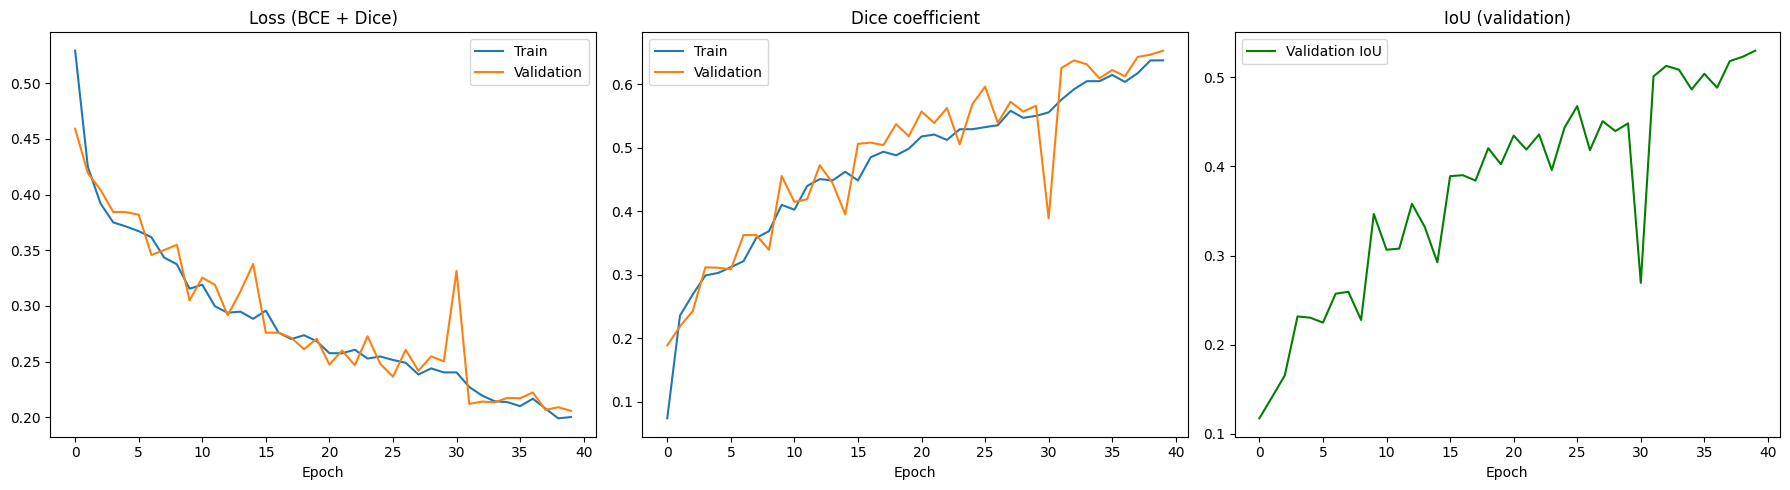

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss (BCE + Dice)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_dice"], label="Train")
axes[1].plot(history["val_dice"], label="Validation")
axes[1].set_title("Dice coefficient")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["val_iou"], label="Validation IoU", color="green")
axes[2].set_title("IoU (validation)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()


## 12. Visualisation des prédictions sur le set de validation

Modèle chargé (epoch 40, val_dice=0.6526)


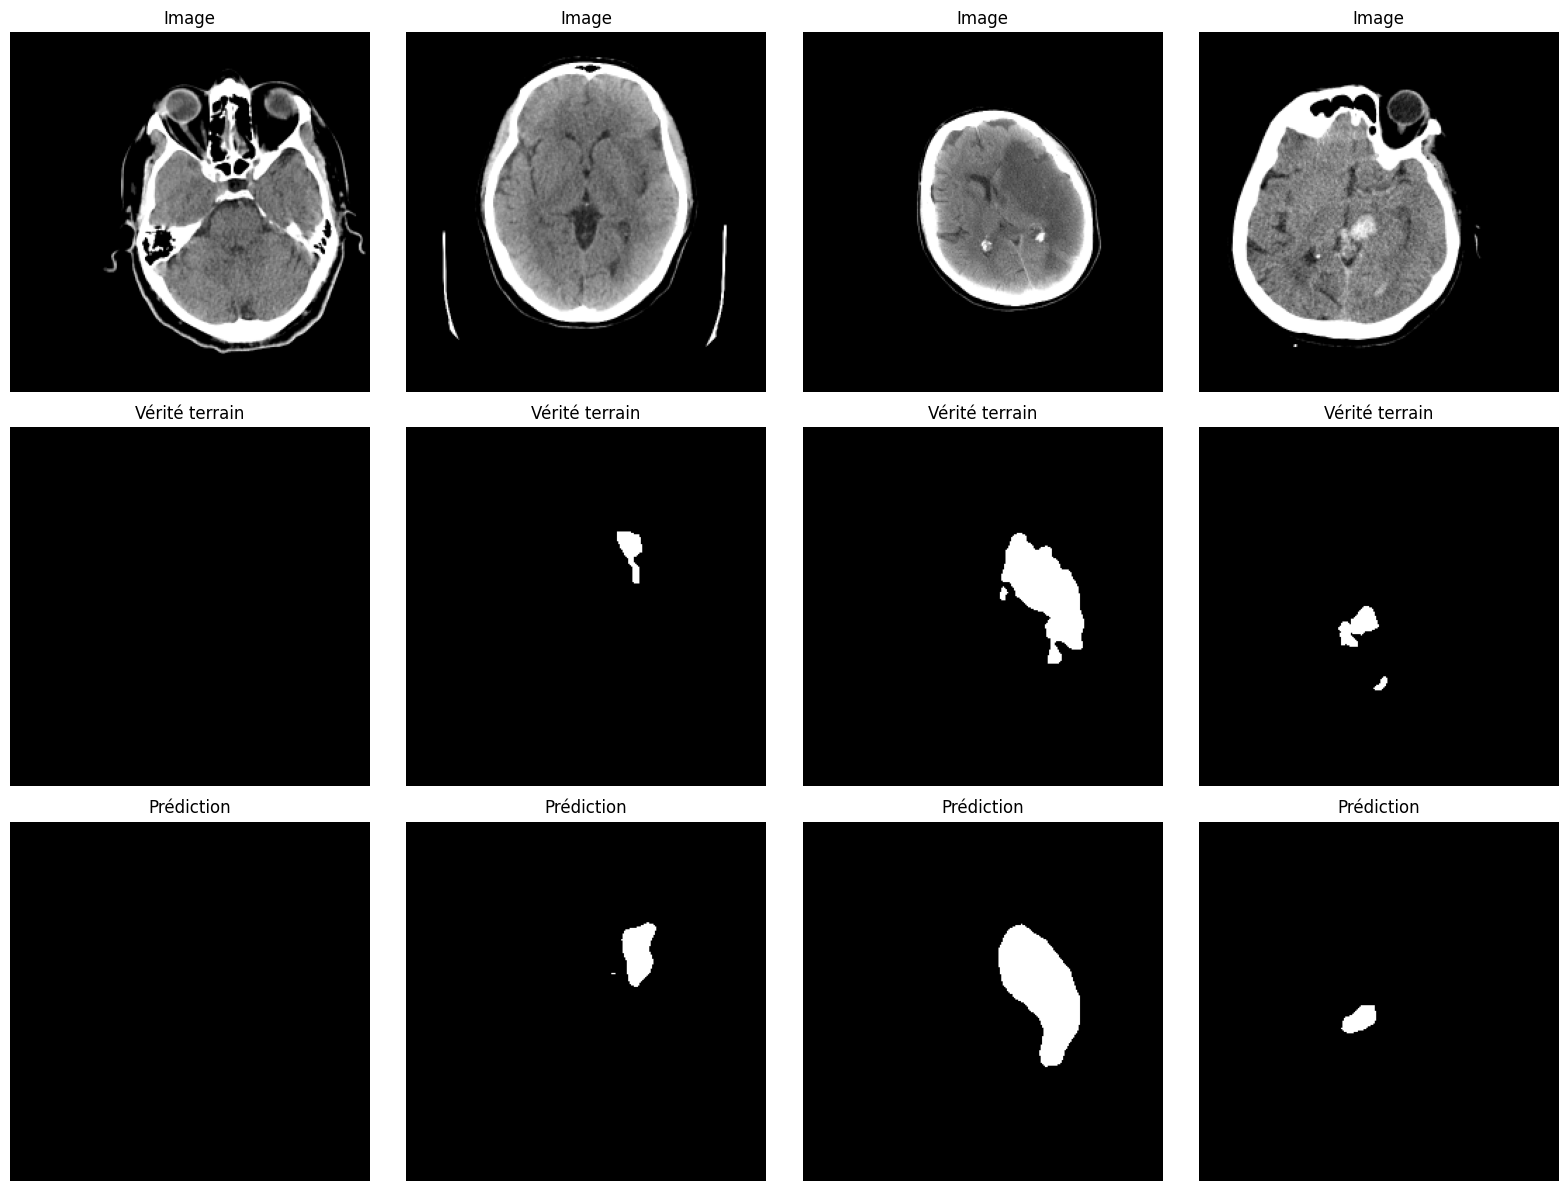

In [12]:
checkpoint = torch.load(CONFIG.BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Modèle chargé (epoch {checkpoint['epoch']}, val_dice={checkpoint['val_dice']:.4f})")

images, masks = next(iter(val_loader))
images_gpu = images.to(device)

with torch.no_grad():
    logits = model(images_gpu)
    preds = (torch.sigmoid(logits) > CONFIG.THRESHOLD).float().cpu()

n_show = min(4, images.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))
for i in range(n_show):
    img = denormalize(images[i])
    axes[0, i].imshow(img.squeeze(), cmap="gray" if CONFIG.IN_CHANNELS == 1 else None)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")

    axes[1, i].imshow(masks[i, 0], cmap="gray")
    axes[1, i].set_title("Vérité terrain")
    axes[1, i].axis("off")

    axes[2, i].imshow(preds[i, 0], cmap="gray")
    axes[2, i].set_title("Prédiction")
    axes[2, i].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/predictions_sample.png", dpi=150)
plt.show()


## 12bis. Évaluation finale sur External_Test (vrais masques, jamais vus à l'entraînement)

`External_Test` n'a jamais été utilisé pour l'entraînement ni la validation : c'est le seul endroit avec des masques réels (pas extraits d'un overlay), donc c'est la mesure la plus fiable de la performance du modèle.

External_Test — 200 images
Dice moyen : 0.8452 | Dice médian : 1.0000
IoU moyen  : 0.8181


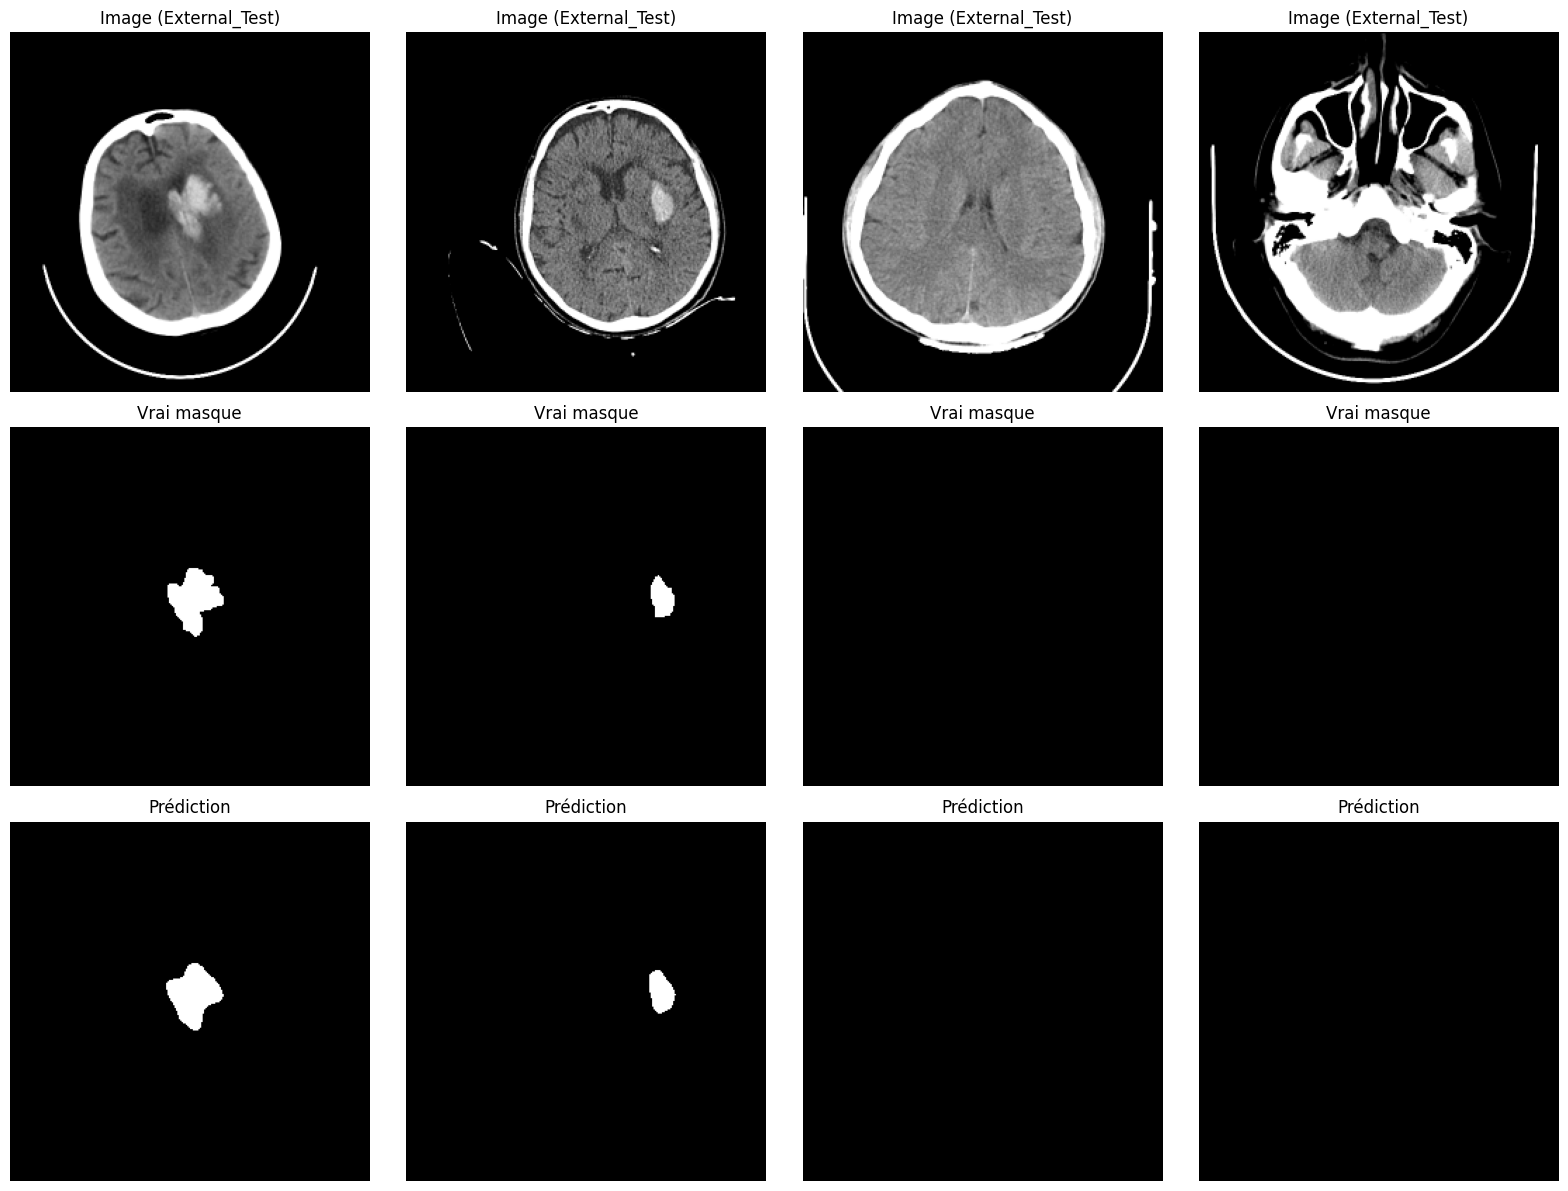

In [13]:
class ExternalTestDataset(Dataset):
    def __init__(self, pairs, img_size, in_channels=1):
        self.pairs = pairs
        self.transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.5,) * in_channels, std=(0.5,) * in_channels),
            ToTensorV2(),
        ])
        self.in_channels = in_channels

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        if self.in_channels == 1:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)[..., None]
        else:
            image = cv2.cvtColor(cv2.imread(img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        aug = self.transform(image=image, mask=mask)
        m = aug["mask"]
        m = m.unsqueeze(0) if m.ndim == 2 else m
        return aug["image"], m.float()


external_dataset = ExternalTestDataset(external_test_pairs, CONFIG.IMG_SIZE, CONFIG.IN_CHANNELS)
external_loader = DataLoader(external_dataset, batch_size=CONFIG.BATCH_SIZE, shuffle=False,
                              num_workers=CONFIG.NUM_WORKERS, pin_memory=True)

model.eval()
ext_dice_scores, ext_iou_scores = [], []
with torch.no_grad():
    for images, masks in external_loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        preds = (torch.sigmoid(logits) > CONFIG.THRESHOLD).float()

        inter = (preds * masks).sum(dim=(1, 2, 3))
        union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
        dice = (2 * inter + 1e-6) / (union + 1e-6)
        iou = (inter + 1e-6) / (union - inter + 1e-6)

        ext_dice_scores.extend(dice.cpu().numpy().tolist())
        ext_iou_scores.extend(iou.cpu().numpy().tolist())

print(f"External_Test — {len(external_test_pairs)} images")
print(f"Dice moyen : {np.mean(ext_dice_scores):.4f} | Dice médian : {np.median(ext_dice_scores):.4f}")
print(f"IoU moyen  : {np.mean(ext_iou_scores):.4f}")

# Aperçu visuel de quelques prédictions sur External_Test
images, masks = next(iter(external_loader))
images_gpu = images.to(device)
with torch.no_grad():
    logits = model(images_gpu)
    preds = (torch.sigmoid(logits) > CONFIG.THRESHOLD).float().cpu()

n_show = min(4, images.shape[0])
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))
for i in range(n_show):
    img = denormalize(images[i])
    axes[0, i].imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
    axes[0, i].set_title("Image (External_Test)"); axes[0, i].axis("off")
    axes[1, i].imshow(masks[i, 0].numpy(), cmap="gray")
    axes[1, i].set_title("Vrai masque"); axes[1, i].axis("off")
    axes[2, i].imshow(preds[i, 0].numpy(), cmap="gray")
    axes[2, i].set_title("Prédiction"); axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## 13. Sauvegarde finale et fonction d'inférence

Le meilleur modèle est déjà sauvegardé pendant l'entraînement dans `CONFIG.BEST_MODEL_PATH`
(`/kaggle/working/checkpoints/unet_best.pth`), téléchargeable depuis l'onglet **Output** du notebook Kaggle.


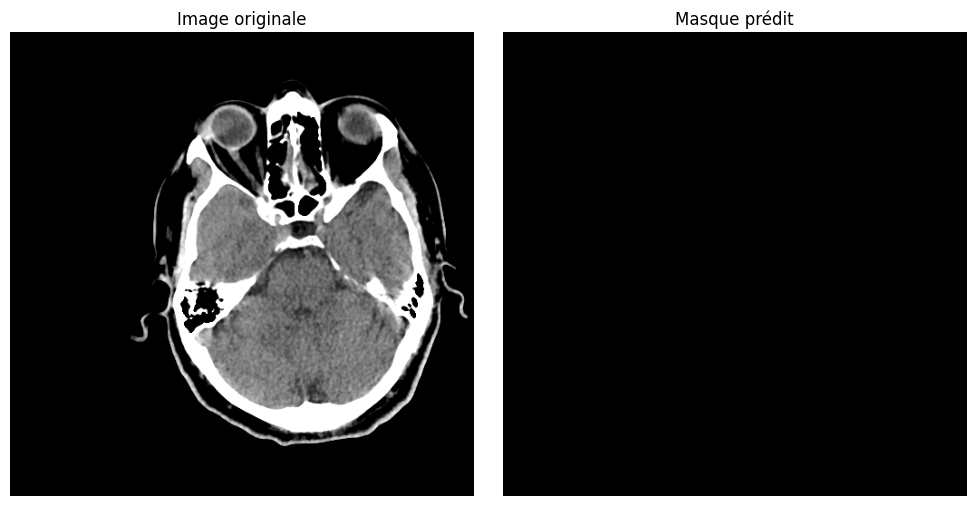


Fichiers sauvegardés dans /kaggle/working/ :
 - /kaggle/working/checkpoints/unet_best.pth
 - /kaggle/working/training_curves.png
 - /kaggle/working/predictions_sample.png


In [14]:
def predict_image(image_path, model, img_size, in_channels=1, threshold=0.5):
    """Charge une image, prédit son masque de segmentation, retourne (image_originale, masque_predit)."""
    if in_channels == 1:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        image_in = image[..., None]
    else:
        image = cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        image_in = image

    transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.5,) * in_channels, std=(0.5,) * in_channels),
        ToTensorV2(),
    ])
    tensor = transform(image=image_in)["image"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        mask_pred = (prob > threshold).astype(np.uint8) * 255

    mask_pred = cv2.resize(mask_pred, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    return image, mask_pred


# Exemple d'utilisation sur une image de validation :
example_img_path, _ = val_pairs[0]
orig_img, pred_mask = predict_image(example_img_path, model, CONFIG.IMG_SIZE, CONFIG.IN_CHANNELS, CONFIG.THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(orig_img, cmap="gray" if CONFIG.IN_CHANNELS == 1 else None)
axes[0].set_title("Image originale")
axes[0].axis("off")
axes[1].imshow(pred_mask, cmap="gray")
axes[1].set_title("Masque prédit")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("\nFichiers sauvegardés dans /kaggle/working/ :")
print(" -", CONFIG.BEST_MODEL_PATH)
print(" - /kaggle/working/training_curves.png")
print(" - /kaggle/working/predictions_sample.png")
